In [2]:
from sklearn.datasets import load_sample_image
img = load_sample_image("china.jpg")
og = img
from matplotlib import pyplot as plt


In [3]:
img.shape

(427, 640, 3)

In [4]:
img.size

819840

In [5]:
print(img.dtype)

uint8


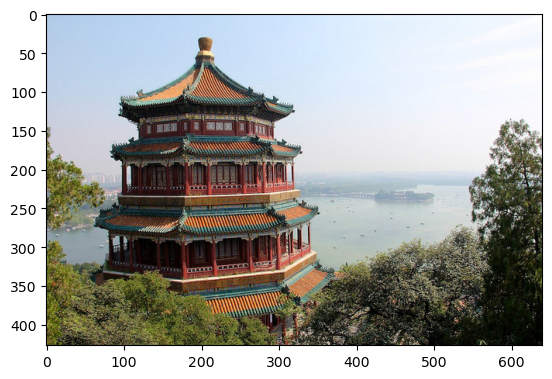

In [6]:
plt.imshow(img)

In [7]:
h,w , c =img.shape

In [8]:
h , w , c

(427, 640, 3)

In [9]:
img[0].shape

(640, 3)

Here right now for evry pixel it shows 3 rgb values
Now what we do is make both row and column same usnig reshape
So that every pixel as one row of R, G ,B
(427, 640, 3) becomes ----> (273280, 3)


In [10]:
img = img.reshape(-1 , 3)  # -1 mean we dont know the row size you do it

In [11]:
img

array([[174, 201, 231],
       [174, 201, 231],
       [174, 201, 231],
       ...,
       [ 43,  49,  39],
       [ 13,  21,   6],
       [ 15,  24,   7]], shape=(273280, 3), dtype=uint8)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [13]:
X_scaled = StandardScaler().fit_transform(img)
ks = []
inertias = []
scores = []
for k in range(2,8):
    km = KMeans(k , n_init= 10 , random_state=42)
    km.fit(X_scaled)
    inertia = km.inertia_
    ks.append(k)
    inertias.append(inertia)
    label = km.labels_
    score = silhouette_score(X_scaled , label , sample_size = 5000 , random_state = 42)
    scores.append(score)
    print(f"k={k}  inertia={km.inertia_:.2f}, score={score:.2f}" ,   flush=True)


k=2  inertia=145860.00, score=0.70
k=3  inertia=74863.19, score=0.61
k=4  inertia=52123.01, score=0.55
k=5  inertia=38674.06, score=0.50
k=6  inertia=31327.79, score=0.47
k=7  inertia=27254.78, score=0.45


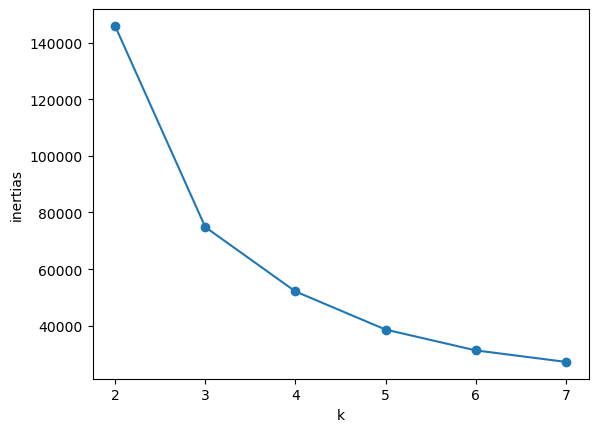

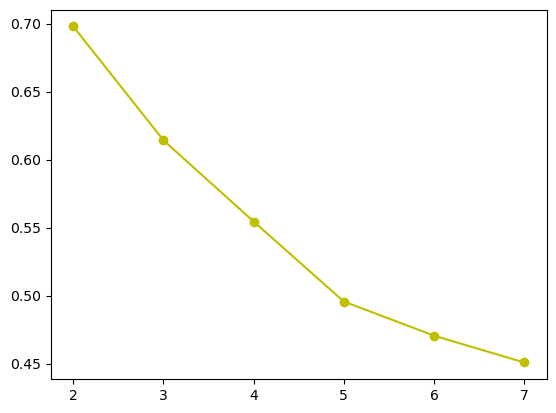

In [14]:
from matplotlib import pyplot as plt    

plt.plot(ks , inertias , marker = 'o')
plt.xlabel('k')
plt.ylabel('inertias')
plt.show()
plt.plot(ks , scores , marker = 'o' , color = 'y')


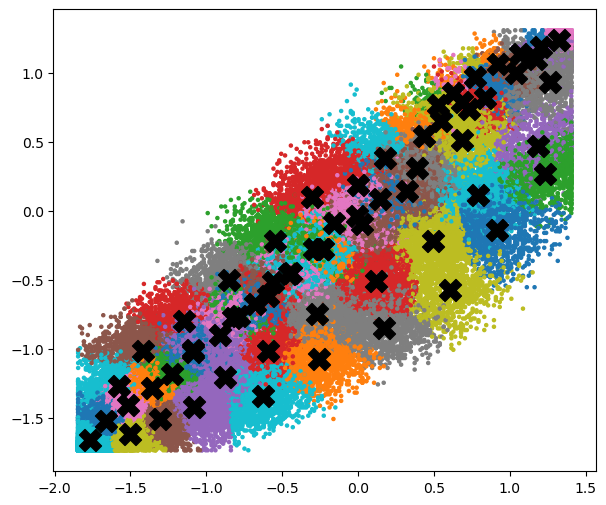

In [15]:
km  = KMeans(64 , n_init=10 , random_state= 42 )
km.fit(X_scaled)
C = km.cluster_centers_

#Lets see this in 3d the clustering with 8 centroids:
plt.figure(figsize=(7,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=km.labels_, cmap='tab10', s=5)
plt.scatter(C[:,0], C[:,1], c='black', marker='X', s=250)
plt.show()

So what to actually use:

k	bits/pixel	look
2–4	1–2	poster art, obviously stylized
8	3	recognizable, visible banding in the sky
16	4	good, minor banding
32	5	near-indistinguishable
256	8	what GIF uses

In [16]:
X = og / 255.0

$X = \frac{x - x_{min}}{x_{max} - x_{min}}$

We use 255 because of how digital images store color information using 8-bit binary numbers.
Computers store colors between 0 and 255
But KMeans works better if numbers are between 0 and 1

In [17]:
X

array([[[0.68235294, 0.78823529, 0.90588235],
        [0.68235294, 0.78823529, 0.90588235],
        [0.68235294, 0.78823529, 0.90588235],
        ...,
        [0.98039216, 0.98431373, 1.        ],
        [0.98039216, 0.98431373, 1.        ],
        [0.98039216, 0.98431373, 1.        ]],

       [[0.6745098 , 0.78039216, 0.89803922],
        [0.67843137, 0.78431373, 0.90196078],
        [0.67843137, 0.78431373, 0.90196078],
        ...,
        [0.98431373, 0.98823529, 1.        ],
        [0.98431373, 0.98823529, 1.        ],
        [0.98431373, 0.98823529, 1.        ]],

       [[0.68235294, 0.78823529, 0.90588235],
        [0.68235294, 0.78823529, 0.90588235],
        [0.68235294, 0.78823529, 0.90588235],
        ...,
        [0.98823529, 0.99215686, 1.        ],
        [0.98823529, 0.99215686, 1.        ],
        [0.98823529, 0.99215686, 1.        ]],

       ...,

       [[0.34509804, 0.31372549, 0.02745098],
        [0.57647059, 0.54117647, 0.27058824],
        [0.47843137, 0

In [18]:
X
pixels = X.reshape(-1, 3)
pixels

array([[0.68235294, 0.78823529, 0.90588235],
       [0.68235294, 0.78823529, 0.90588235],
       [0.68235294, 0.78823529, 0.90588235],
       ...,
       [0.16862745, 0.19215686, 0.15294118],
       [0.05098039, 0.08235294, 0.02352941],
       [0.05882353, 0.09411765, 0.02745098]], shape=(273280, 3))

[[0.82404759 0.85468635 0.88413119]
 [0.28302308 0.25523425 0.18494591]]
[0 0 0 ... 1 1 1]


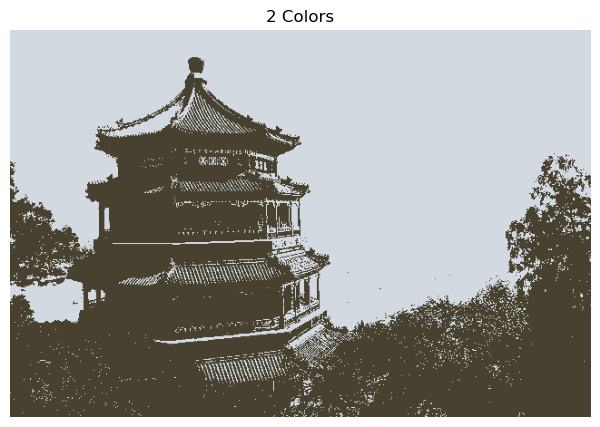

In [23]:
k_values = [2,4,8,16,32,64]
plt.figure(figsize=(18,10))

for i , k in enumerate(k_values):
    km = KMeans(n_clusters=k , n_init=10 , random_state=42)
    labels = km.fit_predict(pixels)
    compressed = km.cluster_centers_[labels]
    print(km.cluster_centers_)
    print(labels)
    #print(compressed)
    compressed = compressed.reshape(X.shape)
    plt.subplot(2,3,i+1)
    plt.imshow(compressed)
    plt.title(f"{k} Colors")
    plt.axis("off")
    break
plt.tight_layout()
plt.show()


    